In [1]:
import sys
import os
import numpy as np
import datetime

import matplotlib.pyplot as plt
sys.path.append('..//')
from utils_mitgcm import open_mitgcm_ds_from_config
import xmitgcm as xm

In [2]:
model = 'geneva_dummy_7ms'
mitgcm_config, ds_vel = open_mitgcm_ds_from_config('..//config.json', model)

In [3]:
def repair_coord(ds, grid_resolution):
    ds['YC'] = np.arange(1, len(ds['YC'])+1) * grid_resolution - grid_resolution/2
    ds['XC'] = np.arange(1, len(ds['XC'])+1) * grid_resolution - grid_resolution/2
    ds['YG'] = np.arange(0, len(ds['YG'])) * grid_resolution
    ds['XG'] = np.arange(0, len(ds['XG'])) * grid_resolution

    return ds

In [4]:
dt_save = 3600
res_grid = 200

## Velocity

In [5]:
ds_vel = repair_coord(ds_vel, res_grid)

# Wind stress

In [9]:
ds_ws = xm.open_mdsdataset(
    mitgcm_config['datapath'],
    grid_dir=mitgcm_config['gridpath'],
    ref_date=mitgcm_config['ref_date'],
    prefix='wind_stress',
    delta_t=mitgcm_config['dt'],
    endian='>')

## Momentum diagnostic

In [6]:
ds_mom = xm.open_mdsdataset(
    mitgcm_config['datapath'],
    grid_dir=mitgcm_config['gridpath'],
    ref_date=mitgcm_config['ref_date'],
    prefix='u_mom_diag',
    delta_t=mitgcm_config['dt'],
    endian='>')

In [7]:
ds_mom = repair_coord(ds_mom, res_grid)

In [8]:
ds_mom.Um_Ext.isel(time=-1,Z=0).plot()

AttributeError: 'Dataset' object has no attribute 'Um_Ext'

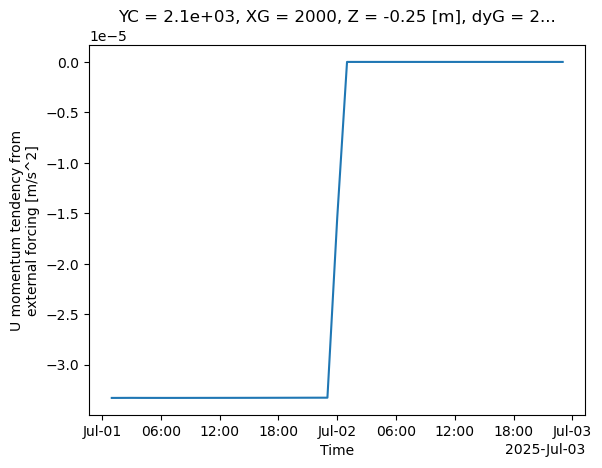

In [37]:
ds_mom.Um_Ext.isel(XG=10,YC=10,Z=0).plot()

# Momentum analysis - U

In [38]:
xc = 150
yc = 80
z = 0

In [39]:
USidDrag = ds_mom.USidDrag.isel(XG=xc,YC=yc,Z=z)
Um_ImplD = ds_mom.Um_ImplD.isel(XG=xc,YC=yc,Z=z)
Um_Advec = ds_mom.Um_Advec.isel(XG=xc,YC=yc,Z=z)
Um_dPhiX = ds_mom.Um_dPhiX.isel(XG=xc,YC=yc,Z=z)
Um_Ext = ds_mom.Um_Ext.isel(XG=xc,YC=yc,Z=z)
Um_AdvZ3 = ds_mom.Um_AdvZ3.isel(XG=xc,YC=yc,Z=z)
Um_AdvRe = ds_mom.Um_AdvRe.isel(XG=xc,YC=yc,Z=z)
Um_Diss = ds_mom.Um_Diss.isel(XG=xc,YC=yc,Z=z)
Um_Cori = ds_mom.Um_Cori.isel(XG=xc,YC=yc,Z=z)
AB_gU = ds_mom.AB_gU.isel(XG=xc,YC=yc,Z=z)
UVEL = ds_vel.UVEL.isel(XG=xc,YC=yc,Z=z)

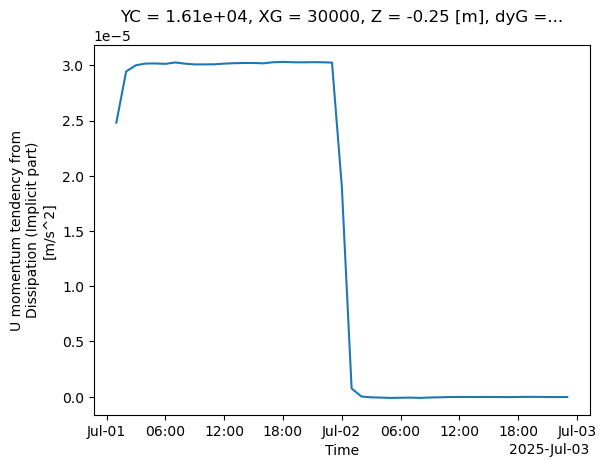

In [40]:
Um_ImplD.plot(label='Um_ImplD')

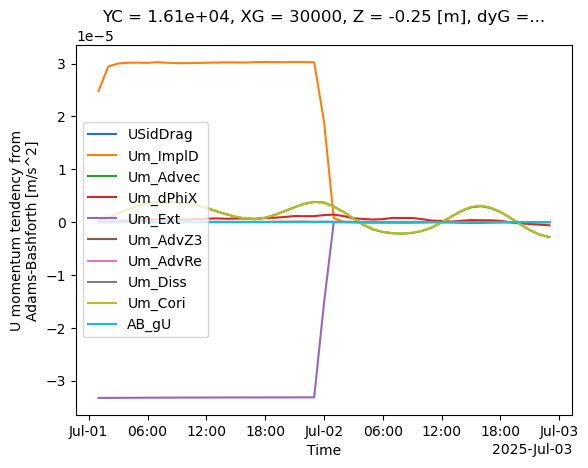

In [41]:
USidDrag.plot(label='USidDrag')
Um_ImplD.plot(label='Um_ImplD')
Um_Advec.plot(label='Um_Advec')
Um_dPhiX.plot(label='Um_dPhiX')
Um_Ext.plot(label='Um_Ext')
Um_AdvZ3.plot(label='Um_AdvZ3')
Um_AdvRe.plot(label='Um_AdvRe')
Um_Diss.plot(label='Um_Diss')
Um_Cori.plot(label='Um_Cori')
AB_gU.plot(label='AB_gU')
plt.legend()

In [42]:
sum_mom = USidDrag+Um_ImplD+Um_Advec+Um_dPhiX+Um_Ext+Um_AdvZ3+Um_AdvRe+Um_Diss+Um_Cori+AB_gU

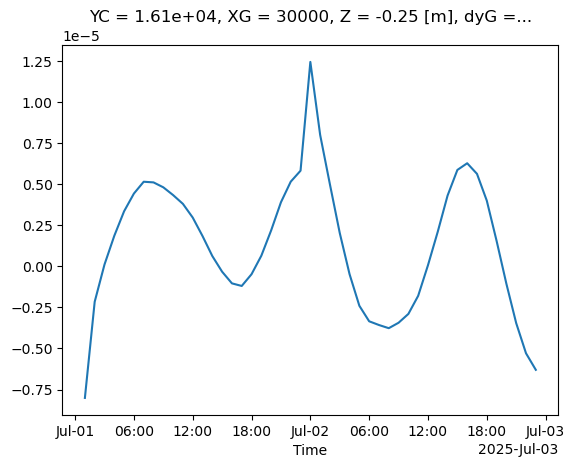

In [43]:
sum_mom.plot()

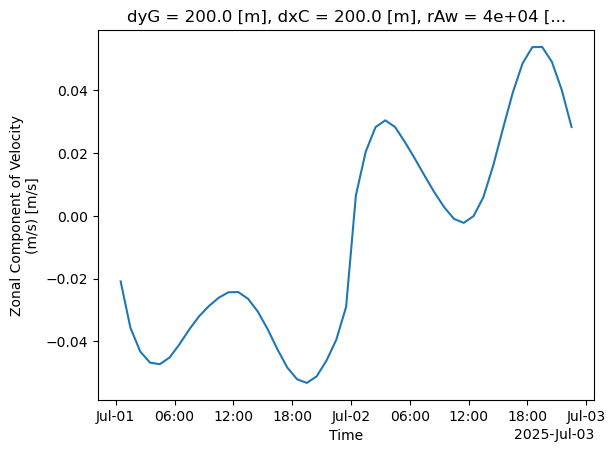

In [44]:
UVEL.plot()

In [45]:
dU_dt = UVEL.diff(dim='time')/dt_save

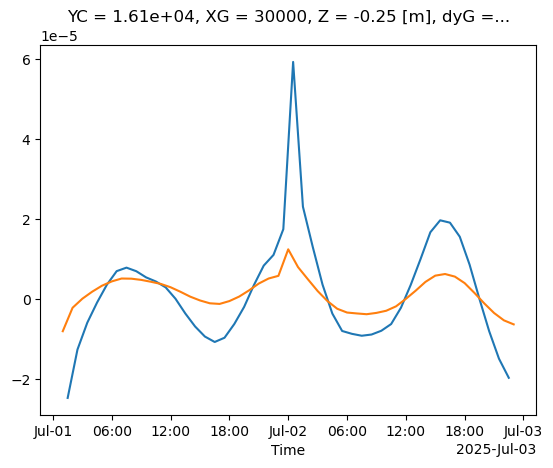

In [46]:
dU_dt.plot()
(sum_mom).plot()

In [47]:
dU_dt.values / sum_mom.values[:-1]

array([ 3.08006217e+00,  5.84315552e+00, -5.27575780e+01, -4.53632548e-01,
        1.07396259e+00,  1.57858671e+00,  1.52796073e+00,  1.36485360e+00,
        1.13036007e+00,  1.01593064e+00,  7.70461494e-01,  3.34504434e-02,
       -1.93855950e+00, -1.08966617e+01,  2.85082766e+01,  1.03278505e+01,
        8.07077919e+00,  1.29304338e+01, -3.00562078e+00,  1.60380695e+00,
        2.14558929e+00,  2.14423953e+00,  3.00044383e+00,  4.76119098e+00,
        2.88603382e+00,  2.62433297e+00,  1.78852586e+00,  7.54666713e+00,
        3.31209171e+00,  2.59070091e+00,  2.55933716e+00,  2.34753411e+00,
        2.29868248e+00,  2.14703920e+00,  1.19765395e+00,  5.20931080e+01,
        4.74167275e+00,  3.87732995e+00,  3.35513859e+00,  3.04385799e+00,
        2.76969047e+00,  2.15848446e+00,  7.70623223e-02,  7.52523253e+00,
        4.30194738e+00,  3.71297654e+00])

In [48]:
UVEL.isel(time=0).values / sum_mom.isel(time=0).values

2603.8954664728412

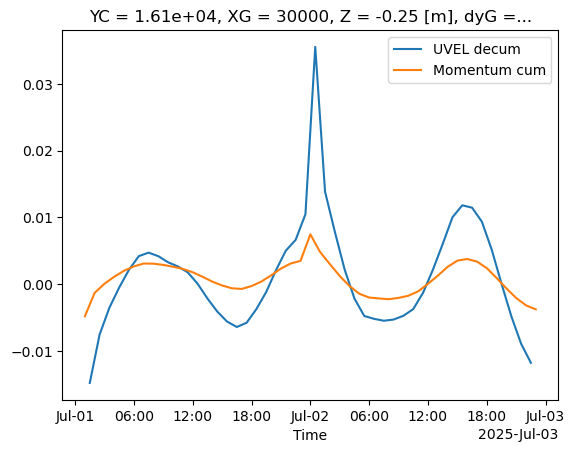

In [49]:
UVEL.diff(dim='time').plot(label='UVEL decum')
(sum_mom*dt_save).plot(label='Momentum cum')
plt.legend()

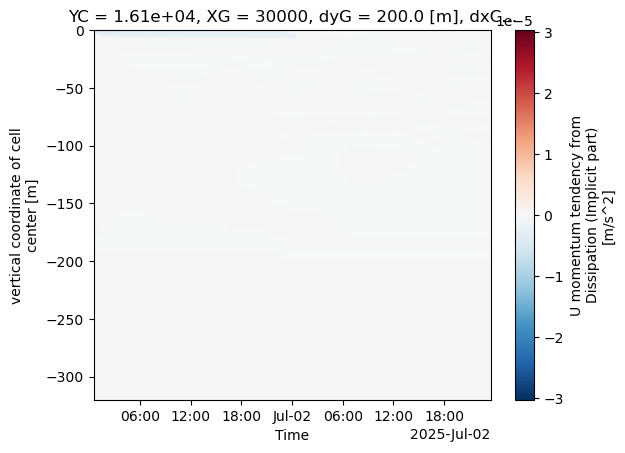

In [50]:
ds_mom.Um_ImplD.isel(XG=xc,YC=yc).plot(x='time')

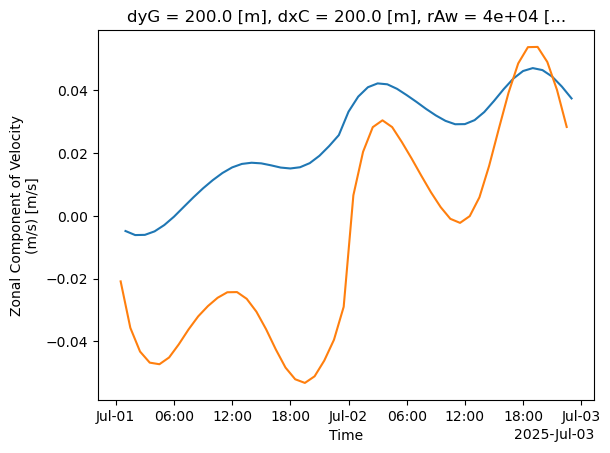

In [51]:
(sum_mom.cumsum()*dt_save).plot()
UVEL.plot()

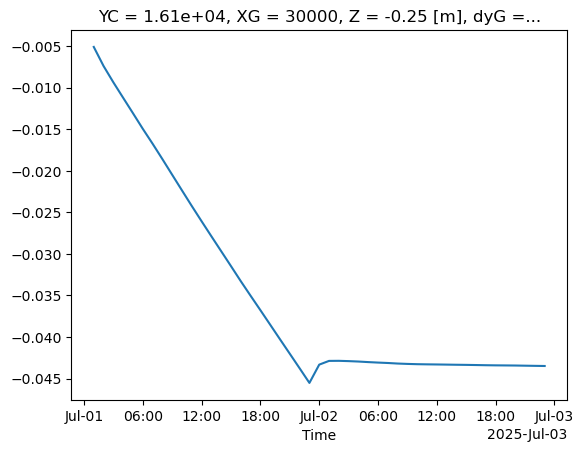

In [52]:
((Um_Ext + Um_ImplD).cumsum()*dt_save).plot(label='Um_ImplD')